In [1]:
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.preprocessing import MinMaxScaler

sys.path.append(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')
from src.fraud_utils import (
    engineer_features, engineer_features_xgb,
    evaluate_model, prepare_for_lr
)

os.chdir(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')


In [2]:
pipeline_lr        = joblib.load('models/pipeline_lr.pkl')
pipeline_xgb_final = joblib.load('models/pipeline_xgb_final.pkl')
pipeline_if        = joblib.load('models/pipeline_if.pkl')
xgb_v3             = joblib.load('models/xgb_v3_best.pkl')

X_val,  y_val  = joblib.load('data/val_set.pkl')
X_test, y_test = joblib.load('data/test_set.pkl')

val_scores   = joblib.load('models/val_scores.pkl')
shap_results = joblib.load('models/shap_results.pkl')

print(f"X_test shape   : {X_test.shape}")
print(f"y_test shape   : {y_test.shape}")
print(f"Test fraud rate: {y_test.mean():.4f}")

assert abs(y_test.mean() - 0.0553) < 0.001, \
    f"STOP — Test fraud rate {y_test.mean():.4f} deviates from expected 0.0553"

print("\nSetup verified ✅ — test set unlocked")
print(f"Total test transactions : {len(y_test):,}")
print(f"Total test fraud cases  : {y_test.sum():,}")


X_test shape   : (150000, 19)
y_test shape   : (150000,)
Test fraud rate: 0.0553

Setup verified ✅ — test set unlocked
Total test transactions : 150,000
Total test fraud cases  : 8,288


In [3]:
for fname in ['pipeline_lr.pkl', 'pipeline_xgb_final.pkl', 'pipeline_if.pkl', 'xgb_v3_best.pkl']:
    size = os.path.getsize(f'models/{fname}')
    print(f"{fname:<30} {size:>10,} bytes")

print()
for label, pipeline in [('LR', pipeline_lr), ('XGB', pipeline_xgb_final)]:
    ct = pipeline.named_steps['preprocessor']
    print(f"{label} pipeline — expected columns:")
    for name, transformer, cols in ct.transformers_:
        print(f"  [{name}] {cols}")
    print()


pipeline_lr.pkl                     8,026 bytes
pipeline_xgb_final.pkl            227,776 bytes
pipeline_if.pkl                 1,183,445 bytes
xgb_v3_best.pkl                   222,726 bytes

LR pipeline — expected columns:
  [log_scale] ['transaction_amount', 'account_balance', 'account_age_years', 'distance_from_home_km', 'time_since_last_txn_hrs']
  [scale] ['customer_age', 'credit_score', 'num_prev_transactions', 'transaction_freq_monthly', 'hour_of_day', 'failed_attempts', 'compound_risk_score']
  [ohe] ['merchant_category', 'payment_method', 'device_type', 'country']
  [pass_binary] ['is_weekend', 'is_night_transaction', 'is_international', 'pin_changed_recently', 'high_risk_attempts', 'night_international', 'high_risk_merchant', 'high_value_transaction']

XGB pipeline — expected columns:
  [ohe] ['merchant_category', 'payment_method', 'device_type', 'country']
  [pass_binary] ['is_weekend', 'is_night_transaction', 'is_international', 'pin_changed_recently', 'high_risk_attempts'

In [4]:
# LR requires compound features reconstructed from raw X_test
X_test_lr = prepare_for_lr(X_test)

missing = [c for c in ['compound_risk_score', 'night_international', 'high_risk_merchant',
                        'high_risk_attempts', 'high_value_transaction']
           if c not in X_test_lr.columns]
print(f"Missing columns : {missing if missing else 'None ✅'}")
print(f"X_test_lr shape : {X_test_lr.shape}")

lr_test_probs  = pipeline_lr.predict_proba(X_test_lr)[:, 1]
xgb_test_probs = pipeline_xgb_final.predict_proba(X_test)[:, 1]

if_test_scores = pipeline_if.decision_function(X_test_lr)
if_test_probs  = MinMaxScaler().fit_transform(
    (-if_test_scores).reshape(-1, 1)
).ravel()

print(f"\nLR probs  — min: {lr_test_probs.min():.4f}  max: {lr_test_probs.max():.4f}")
print(f"XGB probs — min: {xgb_test_probs.min():.4f}  max: {xgb_test_probs.max():.4f}")
print(f"IF probs  — min: {if_test_probs.min():.4f}  max: {if_test_probs.max():.4f}")


Missing columns : None ✅
X_test_lr shape : (150000, 24)

LR probs  — min: 0.1750  max: 0.9743
XGB probs — min: 0.3450  max: 0.6956
IF probs  — min: 0.0000  max: 1.0000


In [5]:
# val_auc_pr and val_fraud_pct passed for overfitting check (±0.01 tolerance)
results_test = []
results_test.append(evaluate_model(
    'Logistic Regression', y_test, lr_test_probs,
    val_auc_pr=0.1246, val_fraud_pct=26.53))
results_test.append(evaluate_model(
    'XGBoost V3',          y_test, xgb_test_probs,
    val_auc_pr=0.1243, val_fraud_pct=26.30))
results_test.append(evaluate_model(
    'Isolation Forest',    y_test, if_test_probs,
    val_auc_pr=0.0983, val_fraud_pct=21.64))

test_comparison_df = pd.DataFrame(results_test)
test_comparison_df.to_csv('models/test_set_comparison.csv', index=False)

print("\n── Summary Table ─────────────────────────────────────────────────────")
print(test_comparison_df[
    ['Model', 'AUC_PR', 'AUC_ROC', 'F1', 'Lift_10pct', 'Fraud_10pct']
].to_string(index=False))
print("\nTest set evaluation complete ✅")



── Logistic Regression ────────────────────────────────────
  Precision  : 0.1099
  Recall     : 0.5872
  F1         : 0.1851
  AUC-ROC    : 0.7213
  AUC-PR     : 0.1232  (val: 0.1246  diff: -0.0014)  ✅
  Lift@10%  : 2.68x
  Fraud@10% : 26.83%  (val: 26.53%)
  Legit/Fraud: 8.1x  (39,437 legitimate disrupted per 4,867 fraud caught)

── XGBoost V3 ─────────────────────────────────────────────
  Precision  : 0.1160
  Recall     : 0.5637
  F1         : 0.1923
  AUC-ROC    : 0.7227
  AUC-PR     : 0.1218  (val: 0.1243  diff: -0.0025)  ✅
  Lift@10%  : 2.63x
  Fraud@10% : 26.29%  (val: 26.30%)
  Legit/Fraud: 7.6x  (35,619 legitimate disrupted per 4,672 fraud caught)

── Isolation Forest ───────────────────────────────────────
  Precision  : 0.1367
  Recall     : 0.1003
  F1         : 0.1157
  AUC-ROC    : 0.6447
  AUC-PR     : 0.0966  (val: 0.0983  diff: -0.0017)  ✅
  Lift@10%  : 2.17x
  Fraud@10% : 21.73%  (val: 21.64%)
  Legit/Fraud: 6.3x  (5,248 legitimate disrupted per 831 fraud caught)



In [6]:
print("LR probability distribution on test set:")
for thresh in [0.50, 0.45, 0.40, 0.30]:
    print(f"  Transactions scored above {thresh:.2f} : {(lr_test_probs >= thresh).sum():,}")
print(f"  Median probability             : {np.median(lr_test_probs):.4f}")

print("\nXGB probability distribution on test set:")
print(f"  Transactions scored above 0.50 : {(xgb_test_probs >= 0.50).sum():,}")
print(f"  Median probability             : {np.median(xgb_test_probs):.4f}")


LR probability distribution on test set:
  Transactions scored above 0.50 : 44,304
  Transactions scored above 0.45 : 65,704
  Transactions scored above 0.40 : 88,651
  Transactions scored above 0.30 : 97,232
  Median probability             : 0.4333

XGB probability distribution on test set:
  Transactions scored above 0.50 : 40,291
  Median probability             : 0.4927


In [7]:
total_fraud = y_test.sum()
total_txns  = len(y_test)
total_legit = total_txns - total_fraud

precision_c, recall_c, thresh_c = precision_recall_curve(y_test, xgb_test_probs)
f1_scores = 2 * (precision_c * recall_c) / (precision_c + recall_c + 1e-8)
best_idx  = f1_scores.argmax()

print("── XGBoost V3 — Operational Decision Table (Usable Range) ──────────")
print(f"  {'Thresh':>7} {'Flagged':>9} {'%Dataset':>9} {'FraudCaught':>12} "
      f"{'%Fraud':>8} {'Precision':>10} {'FPRate':>8} {'Legit/Fraud':>12}")
print(f"  {'─'*7} {'─'*9} {'─'*9} {'─'*12} {'─'*8} {'─'*10} {'─'*8} {'─'*12}")

table_rows = []
for thresh in [0.40, 0.42, 0.44, 0.46, 0.48, 0.50, 0.52, 0.55, 0.57, 0.60, 0.65, 0.70]:
    preds           = (xgb_test_probs >= thresh).astype(int)
    flagged         = preds.sum()
    if flagged == 0:
        continue
    fraud_caught    = (preds * y_test).sum()
    legit_blocked   = flagged - fraud_caught
    precision       = fraud_caught / flagged
    fp_rate         = legit_blocked / total_legit
    pct_fraud       = fraud_caught / total_fraud * 100
    pct_flagged     = flagged / total_txns * 100
    legit_per_fraud = legit_blocked / max(fraud_caught, 1)

    print(f"  {thresh:>7.2f} {flagged:>9,} {pct_flagged:>8.1f}% "
          f"{fraud_caught:>12,} {pct_fraud:>7.1f}% {precision:>10.4f} "
          f"{fp_rate:>7.1%} {legit_per_fraud:>11.1f}x")

    table_rows.append({
        'Threshold'      : thresh,
        'Flagged'        : flagged,
        'Pct_Flagged'    : round(pct_flagged, 2),
        'Fraud_Caught'   : int(fraud_caught),
        'Pct_Fraud'      : round(pct_fraud, 2),
        'Precision'      : round(precision, 4),
        'FP_Rate'        : round(fp_rate, 4),
        'Legit_per_Fraud': round(legit_per_fraud, 1)
    })

print(f"\n  F1-maximizing threshold : {thresh_c[best_idx]:.4f}")
print(f"  Precision: {precision_c[best_idx]:.4f}  Recall: {recall_c[best_idx]:.4f}  F1: {f1_scores[best_idx]:.4f}")

pd.DataFrame(table_rows).to_csv('models/threshold_decision_table.csv', index=False)
print("Threshold table saved ✅")


── XGBoost V3 — Operational Decision Table (Usable Range) ──────────
   Thresh   Flagged  %Dataset  FraudCaught   %Fraud  Precision   FPRate  Legit/Fraud
  ─────── ───────── ───────── ──────────── ──────── ────────── ──────── ────────────
     0.40    99,229     66.2%        7,751    93.5%     0.0781   64.6%        11.8x
     0.42    94,777     63.2%        7,557    91.2%     0.0797   61.5%        11.5x
     0.44    94,573     63.0%        7,547    91.1%     0.0798   61.4%        11.5x
     0.46    84,987     56.7%        7,042    85.0%     0.0829   55.0%        11.1x
     0.48    79,941     53.3%        6,790    81.9%     0.0849   51.6%        10.8x
     0.50    40,291     26.9%        4,672    56.4%     0.1160   25.1%         7.6x
     0.52    38,663     25.8%        4,547    54.9%     0.1176   24.1%         7.5x
     0.55    33,678     22.5%        4,101    49.5%     0.1218   20.9%         7.2x
     0.57    25,046     16.7%        3,292    39.7%     0.1314   15.4%         6.6x
     

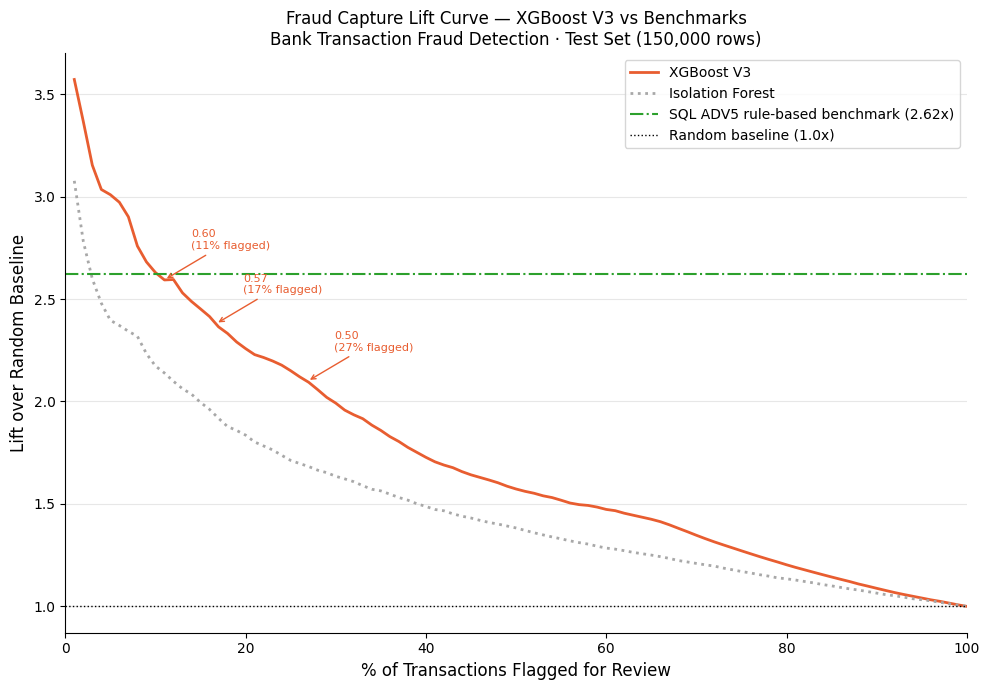

Lift curve saved ✅


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
flagging_rates   = np.arange(0.01, 1.01, 0.01)
total_fraud_test = y_test.sum()

for name, probs, color, ls in [
    ('XGBoost V3',       xgb_test_probs, '#E85D30', '-'),
    ('Isolation Forest', if_test_probs,  '#A8A8A8', ':'),
]:
    sorted_idx = np.argsort(probs)[::-1]
    lifts = [
        (y_test.iloc[sorted_idx[:int(len(y_test) * r)]].sum() / int(len(y_test) * r))
        / (total_fraud_test / len(y_test))
        for r in flagging_rates
    ]
    ax.plot(flagging_rates * 100, lifts, label=name, color=color, linestyle=ls, linewidth=2)

ax.axhline(y=2.62, color='#2CA02C', linestyle='-.', linewidth=1.5,
           label='SQL ADV5 rule-based benchmark (2.62x)')
ax.axhline(y=1.0,  color='black',   linestyle=':',  linewidth=1.0,
           label='Random baseline (1.0x)')

sorted_xgb = np.argsort(xgb_test_probs)[::-1]
for thresh, label in [(0.50, '0.50\n(27% flagged)'),
                      (0.57, '0.57\n(17% flagged)'),
                      (0.60, '0.60\n(11% flagged)')]:
    flagged = (xgb_test_probs >= thresh).sum()
    rate    = flagged / len(y_test)
    top_n   = int(len(y_test) * rate)
    lift_pt = (y_test.iloc[sorted_xgb[:top_n]].sum() / top_n) / (total_fraud_test / len(y_test))
    ax.annotate(label,
                xy=(rate * 100, lift_pt),
                xytext=(rate * 100 + 3, lift_pt + 0.15),
                fontsize=8, color='#E85D30',
                arrowprops=dict(arrowstyle='->', color='#E85D30', lw=1))

ax.set_xlabel('% of Transactions Flagged for Review', fontsize=12)
ax.set_ylabel('Lift over Random Baseline', fontsize=12)
ax.set_title('Fraud Capture Lift Curve — XGBoost V3 vs Benchmarks\n'
             'Bank Transaction Fraud Detection · Test Set (150,000 rows)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('notebook/plots/lift_curve_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lift curve saved ✅")


In [9]:
print("── North Star Answer — Review Queue Recommendation ──────────────────")
print("Which transactions to flag for manual review to maximize fraud caught")
print("while minimizing disruption to legitimate customers?\n")

sorted_idx = np.argsort(xgb_test_probs)[::-1]

for thresh, label in [
    (0.60, "High-precision tier  (score ≥ 0.60)"),
    (0.57, "Balanced tier        (score ≥ 0.57)"),
    (0.50, "High-recall tier     (score ≥ 0.50)"),
]:
    preds           = (xgb_test_probs >= thresh).astype(int)
    flagged         = preds.sum()
    fraud_caught    = (preds * y_test).sum()
    legit_blocked   = flagged - fraud_caught
    precision       = fraud_caught / flagged
    fp_rate         = legit_blocked / total_legit
    pct_fraud       = fraud_caught / total_fraud * 100
    pct_flagged     = flagged / total_txns * 100
    legit_per_fraud = legit_blocked / max(fraud_caught, 1)
    top_n           = int(len(y_test) * pct_flagged / 100)
    lift            = (y_test.iloc[sorted_idx[:top_n]].sum() / top_n) / (total_fraud / total_txns)

    print(f"  {label}")
    print(f"    Flagged      : {flagged:,}  ({pct_flagged:.1f}% of transactions)")
    print(f"    Fraud caught : {fraud_caught:,}  ({pct_fraud:.1f}% of all fraud)")
    print(f"    Legit blocked: {legit_blocked:,}  ({fp_rate:.1%} of legitimate)")
    print(f"    Precision    : {precision:.4f}")
    print(f"    Lift         : {lift:.2f}x")
    print(f"    Legit/fraud  : {legit_per_fraud:.1f}x")
    print()

print("── Operational Recommendation ───────────────────────────────────────")
print("  Tier 1 (≥ 0.60) : Immediate escalation")
print("  Tier 2 (0.50–0.60): Standard review queue")
print("  Tier 3 (< 0.50) : Deprioritize")
print()
print("  Critical constraint: XGBoost beats SQL rules ONLY at ≤11% flagging.")
print("  Do not replace SQL rules — deploy XGBoost for Tier 1 escalation only.")


── North Star Answer — Review Queue Recommendation ──────────────────
Which transactions to flag for manual review to maximize fraud caught
while minimizing disruption to legitimate customers?

  High-precision tier  (score ≥ 0.60)
    Flagged      : 16,489  (11.0% of transactions)
    Fraud caught : 2,363  (28.5% of all fraud)
    Legit blocked: 14,126  (10.0% of legitimate)
    Precision    : 0.1433
    Lift         : 2.59x
    Legit/fraud  : 6.0x

  Balanced tier        (score ≥ 0.57)
    Flagged      : 25,046  (16.7% of transactions)
    Fraud caught : 3,292  (39.7% of all fraud)
    Legit blocked: 21,754  (15.4% of legitimate)
    Precision    : 0.1314
    Lift         : 2.38x
    Legit/fraud  : 6.6x

  High-recall tier     (score ≥ 0.50)
    Flagged      : 40,291  (26.9% of transactions)
    Fraud caught : 4,672  (56.4% of all fraud)
    Legit blocked: 35,619  (25.1% of legitimate)
    Precision    : 0.1160
    Lift         : 2.10x
    Legit/fraud  : 7.6x

── Operational Recommen

In [10]:
joblib.dump({
    'xgb_test': xgb_test_probs,
    'if_test'  : if_test_probs,
    'lr_test'  : lr_test_probs,
    'y_test'   : y_test.values,
}, 'models/test_scores.pkl')

pd.DataFrame({
    'fraud_probability': xgb_test_probs,
    'is_fraud'         : y_test.values,
    'risk_tier'        : pd.cut(
        xgb_test_probs,
        bins  =[0, 0.50, 0.60, 1.0],
        labels=['Tier 3 — Deprioritize',
                'Tier 2 — Standard Review',
                'Tier 1 — Escalate'],
        ordered=False
    )
}).to_csv('data/model_scores_test.csv', index=False)

print("Artifacts saved ✅")
for p in ['models/test_scores.pkl', 'models/test_set_comparison.csv',
          'models/threshold_decision_table.csv',
          'notebook/plots/lift_curve_final.png', 'data/model_scores_test.csv']:
    print(f"  {p}")


Artifacts saved ✅
  models/test_scores.pkl
  models/test_set_comparison.csv
  models/threshold_decision_table.csv
  notebook/plots/lift_curve_final.png
  data/model_scores_test.csv


In [8]:
import joblib
import os
import pandas as pd

# 1 — Main scores file (already have this)
# data/model_scores_test.csv — fraud_probability, is_fraud, risk_tier

os.chdir(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')

# 2 — SHAP results
shap_results = joblib.load('models/shap_results.pkl')
shap_results['shap_df'].to_csv('data/shap_importance.csv', index=False)

# 3 — Threshold decision table (already have this)
# models/threshold_decision_table.csv

# 4 — Raw test features + scores combined (for slicers to work)
X_test, y_test = joblib.load('data/test_set.pkl')
scores = pd.read_csv('data/model_scores_test.csv')

dashboard_df = X_test.copy()
dashboard_df['is_fraud']          = y_test.values
dashboard_df['fraud_probability'] = scores['fraud_probability'].values
dashboard_df['risk_tier']         = scores['risk_tier'].values

dashboard_df.to_csv('data/dashboard_data.csv', index=False)